## EDA - ecommerce sales data

working through the dataset before building the dashboard. 10k rows, 2022-2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

In [2]:
df = pd.read_csv('../data/raw/ecommerce_sales_raw.csv', parse_dates=['order_date'])
df.shape

(10000, 18)

In [3]:
df.head(10)

,order_id,order_date,customer_id,customer_segment,region,sales_channel,category,product_name,unit_price,quantity,discount_pct,discount_amount,revenue,shipping_cost,total_amount,payment_method,order_status,customer_rating
0,ORD000001,2022-06-28,CUST02419,Returning,North,Website,Beauty & Personal Care,Moisturizer,8.63,1,0,0.00,8.63,18.41,27.04,Debit Card,Delivered,3.1
1,ORD000002,2023-07-24,CUST00027,Premium,South,Mobile App,Clothing,Boots,200.22,2,0,0.00,400.44,0.00,400.44,PayPal,Delivered,3.4
2,ORD000003,2022-03-30,CUST02989,Returning,North,Social Media,Home & Kitchen,Blender,64.52,1,20,12.90,51.62,15.09,66.71,Bank Transfer,Delivered,3.6
3,ORD000004,2022-05-23,CUST00188,Returning,East,Social Media,Beauty & Personal Care,Sunscreen,133.39,1,0,0.00,133.39,0.00,133.39,Debit Card,Cancelled,2.0
4,ORD000005,2022-05-27,CUST02496,Returning,Central,Mobile App,Books,History,68.06,1,0,0.00,68.06,16.75,84.81,Debit Card,Delivered,3.5
5,ORD000006,2022-04-25,CUST00939,Premium,East,Mobile App,Beauty & Personal Care,Face Wash,85.76,2,20,34.30,137.22,0.00,137.22,Credit Card,Delivered,4.9
6,ORD000007,2022-10-20,CUST01085,New,Central,Mobile App,Beauty & Personal Care,Perfume,35.83,1,20,7.17,28.66,16.07,44.73,Crypto,Delivered,4.2
7,ORD000008,2022-04-07,CUST00450,New,South,Marketplace,Home & Kitchen,Coffee Maker,498.72,1,5,24.94,473.78,0.00,473.78,Bank Transfer,Delivered,3.8
8,ORD000009,2022-01-24,CUST02787,Premium,Central,Marketplace,Sports & Outdoors,Bicycle,428.00,5,20,428.00,1712.00,0.00,1712.00,PayPal,Delivered,3.9
9,ORD000010,2024-10-22,CUST00732,Returning,North,Marketplace,Books,Fiction Novel,76.67,4,0,0.00,306.68,0.00,306.68,PayPal,Returned,2.3


In [4]:
df.dtypes

order_id                       str
order_date          datetime64[us]
customer_id                    str
customer_segment               str
region                         str
sales_channel                  str
category                       str
product_name                   str
unit_price                 float64
quantity                     int64
discount_pct                 int64
discount_amount            float64
revenue                    float64
shipping_cost              float64
total_amount               float64
payment_method                 str
order_status                   str
customer_rating            float64
dtype: object

In [5]:
# check nulls
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
customer_segment    0
region              0
sales_channel       0
category            0
product_name        0
unit_price          0
quantity            0
discount_pct        0
discount_amount     0
revenue             0
shipping_cost       0
total_amount        0
payment_method      0
order_status        0
customer_rating     0
dtype: int64

In [6]:
# no nulls which is nice since this is synthetic data anyway
# check duplicates
print(df.duplicated().sum())
print(df['order_id'].nunique())

0
10000


In [7]:
df.describe()

,order_date,unit_price,quantity,discount_pct,discount_amount,revenue,shipping_cost,total_amount,customer_rating
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2023-06-30 10:53:11.040000,367.279008,1.939200,8.470500,58.585204,650.164883,3.483901,653.648784,3.570990
min,2022-01-01 00:00:00,5.090000,1.000000,0.000000,0.000000,4.750000,0.000000,8.190000,1.000000
25%,2022-09-27 00:00:00,61.887500,1.000000,0.000000,0.000000,85.370000,0.000000,98.017500,3.100000
50%,2023-06-25 00:00:00,155.300000,1.000000,5.000000,7.000000,237.755000,0.000000,237.755000,3.700000
75%,2024-04-01 00:00:00,411.820000,3.000000,15.000000,43.140000,649.645000,2.742500,649.645000,4.300000
max,2024-12-31 00:00:00,2494.130000,5.000000,30.000000,2875.200000,12084.550000,25.000000,12084.550000,5.000000
std,NaN,523.853166,1.190985,9.225597,161.897800,1186.898024,6.767687,1185.158863,0.971126


unit price goes up to 2500 which makes sense for electronics. discount_pct max is 30 which seems realistic.

In [8]:
# add some time columns
df['year']        = df['order_date'].dt.year
df['month']       = df['order_date'].dt.month
df['month_name']  = df['order_date'].dt.strftime('%b')
df['quarter']     = df['order_date'].dt.quarter
df['day_of_week'] = df['order_date'].dt.day_name()
df['week']        = df['order_date'].dt.isocalendar().week.astype(int)

# rough profit estimate (35% margin assumption)
df['profit'] = (df['revenue'] * 0.35).round(2)

# bucket orders by size
df['revenue_bucket'] = pd.cut(
    df['total_amount'],
    bins=[0, 50, 200, 500, 1000, 99999],
    labels=['<$50', '$50-200', '$200-500', '$500-1K', '>$1K']
)

In [9]:
# save cleaned version
df.to_csv('../data/processed/ecommerce_sales_cleaned.csv', index=False)
print('saved')

saved


---
### revenue trends

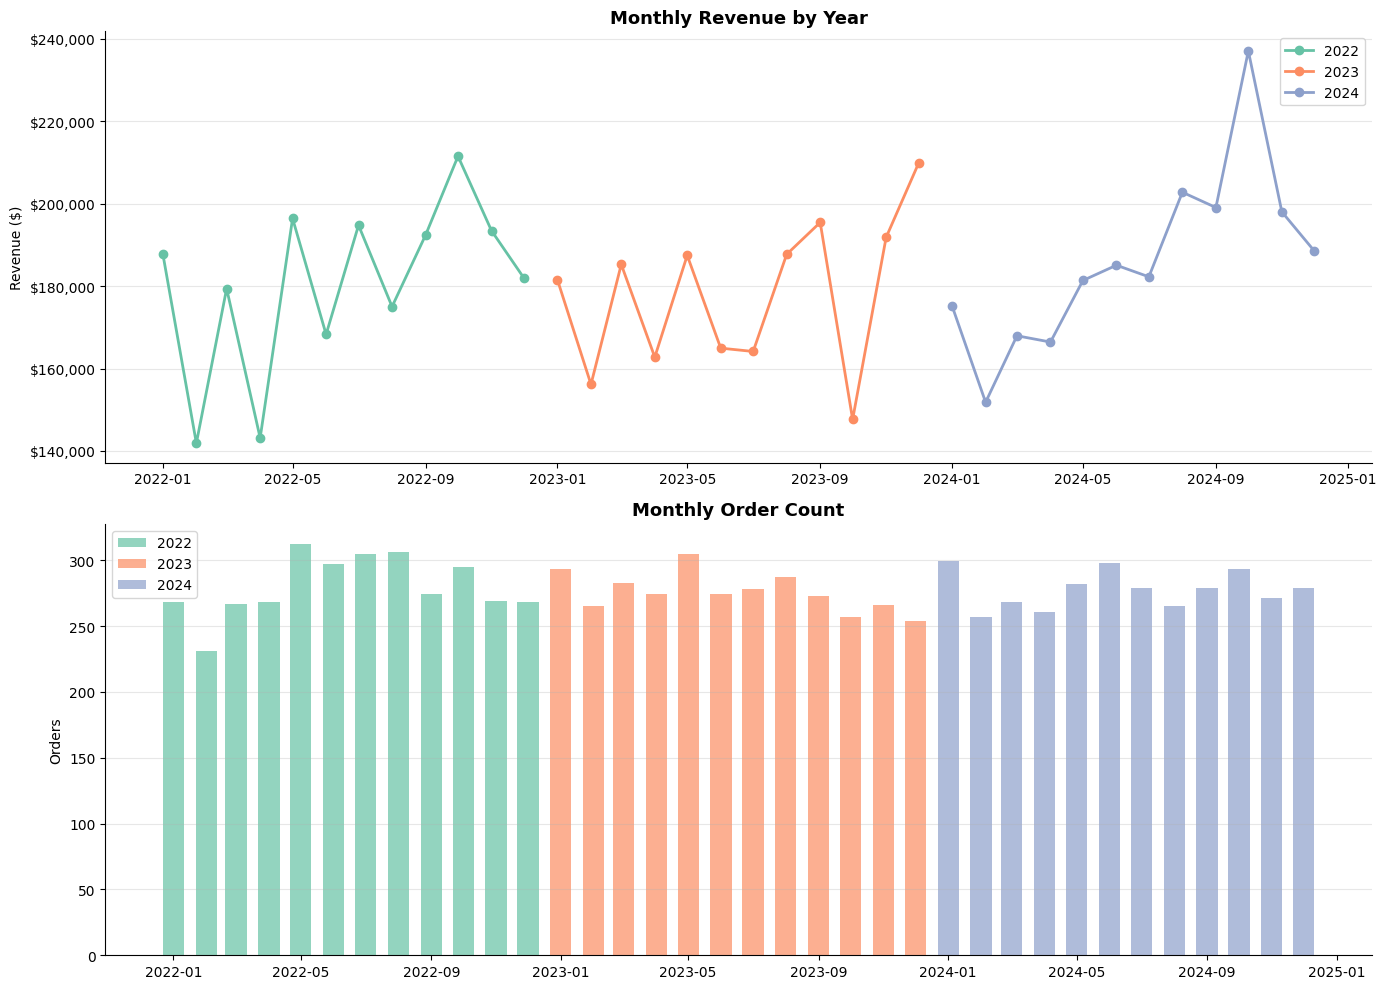

In [10]:
monthly = df.groupby(['year', 'month'])['total_amount'].sum().reset_index()
monthly['period'] = pd.to_datetime(monthly[['year','month']].assign(day=1))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for yr, grp in monthly.groupby('year'):
    axes[0].plot(grp['period'], grp['total_amount'], marker='o', label=str(yr), linewidth=2)
axes[0].set_title('Monthly Revenue by Year', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

monthly_orders = df.groupby(['year','month'])['order_id'].count().reset_index()
monthly_orders['period'] = pd.to_datetime(monthly_orders[['year','month']].assign(day=1))
for yr, grp in monthly_orders.groupby('year'):
    axes[1].bar(grp['period'], grp['order_id'], alpha=0.7, label=str(yr), width=20)
axes[1].set_title('Monthly Order Count', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Orders')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Q4 spike is consistent every year. Nov/Dec are clearly the biggest months.

In [11]:
# yoy summary
yoy = df.groupby('year').agg(
    revenue=('total_amount','sum'),
    orders=('order_id','count'),
    aov=('total_amount','mean'),
    profit=('profit','sum')
).round(2)
yoy['growth_pct'] = yoy['revenue'].pct_change().mul(100).round(1)
yoy

,revenue,orders,aov,profit,growth_pct
year,,,,,
2022,2166101.24,3360,644.67,753922.39,NaN
2023,2134759.03,3309,645.14,743243.71,-1.4
2024,2235627.57,3331,671.16,778409.88,4.7


---
### category breakdown

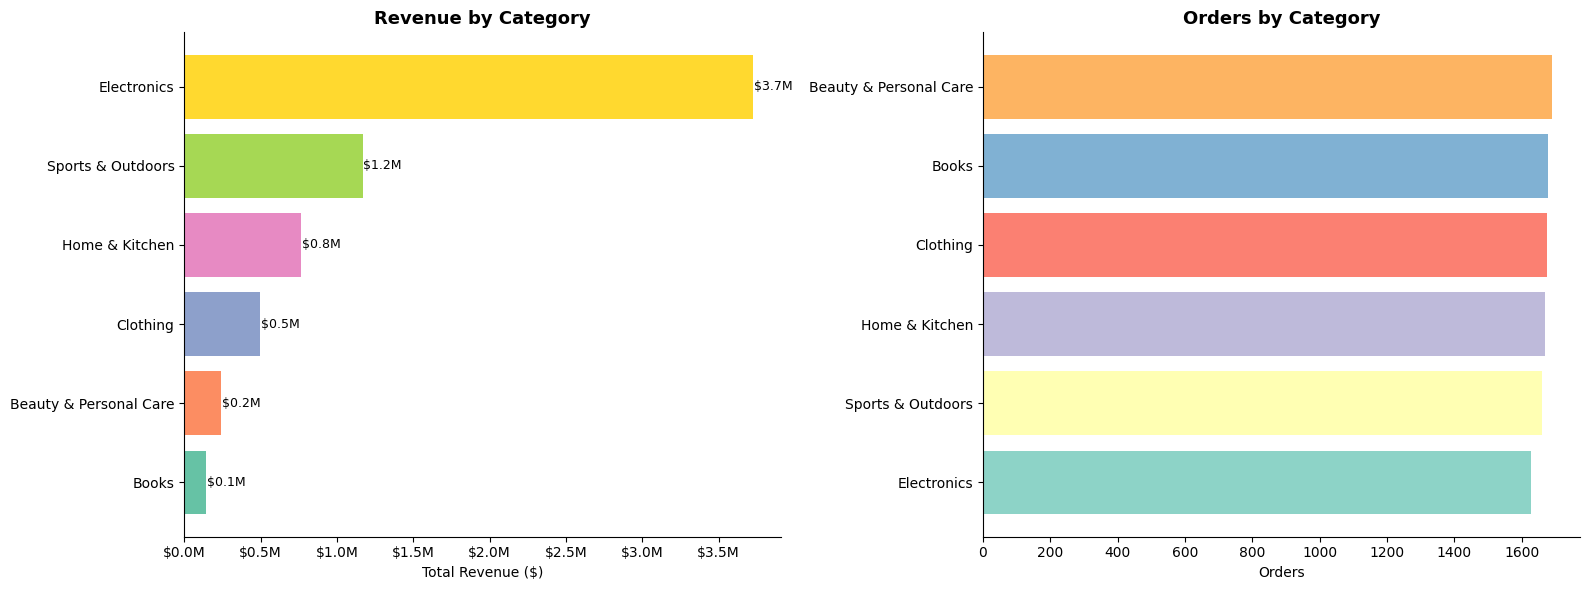

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_rev = df.groupby('category')['total_amount'].sum().sort_values(ascending=True)
bars = axes[0].barh(cat_rev.index, cat_rev.values, color=sns.color_palette('Set2', len(cat_rev)))
axes[0].set_title('Revenue by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, cat_rev.values):
    axes[0].text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:.1f}M', va='center', fontsize=9)

cat_orders = df.groupby('category')['order_id'].count().sort_values(ascending=True)
axes[1].barh(cat_orders.index, cat_orders.values, color=sns.color_palette('Set3', len(cat_orders)))
axes[1].set_title('Orders by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Orders')

plt.tight_layout()
plt.savefig('../images/02_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

electronics leads revenue by a good margin even though the order volume isn't that different from other categories — it's the high unit price. books are the opposite, lots of orders but low revenue per order.

In [13]:
# top 10 products
df.groupby(['category','product_name'])['total_amount'].sum()\
  .sort_values(ascending=False).head(10)

category           product_name
Electronics        Laptop          607078.52
                   Smartphone      563294.15
                   Headphones      560250.10
                   Smart Watch     556749.62
                   Tablet          524871.47
                   Camera          504636.13
                   Speaker         406671.76
Sports & Outdoors  Dumbbells       207185.00
                   Bicycle         204098.91
                   Backpack        198260.36
Name: total_amount, dtype: float64

---
### regional

In [14]:
region_data = df.groupby('region').agg(
    revenue=('total_amount','sum'),
    orders=('order_id','count'),
    aov=('total_amount','mean')
).round(2).sort_values('revenue', ascending=False)

region_data

,revenue,orders,aov
region,,,
Central,1425060.40,2048,695.83
West,1364894.83,2059,662.89
South,1289175.36,2008,642.02
East,1262653.70,1967,641.92
North,1194703.55,1918,622.89


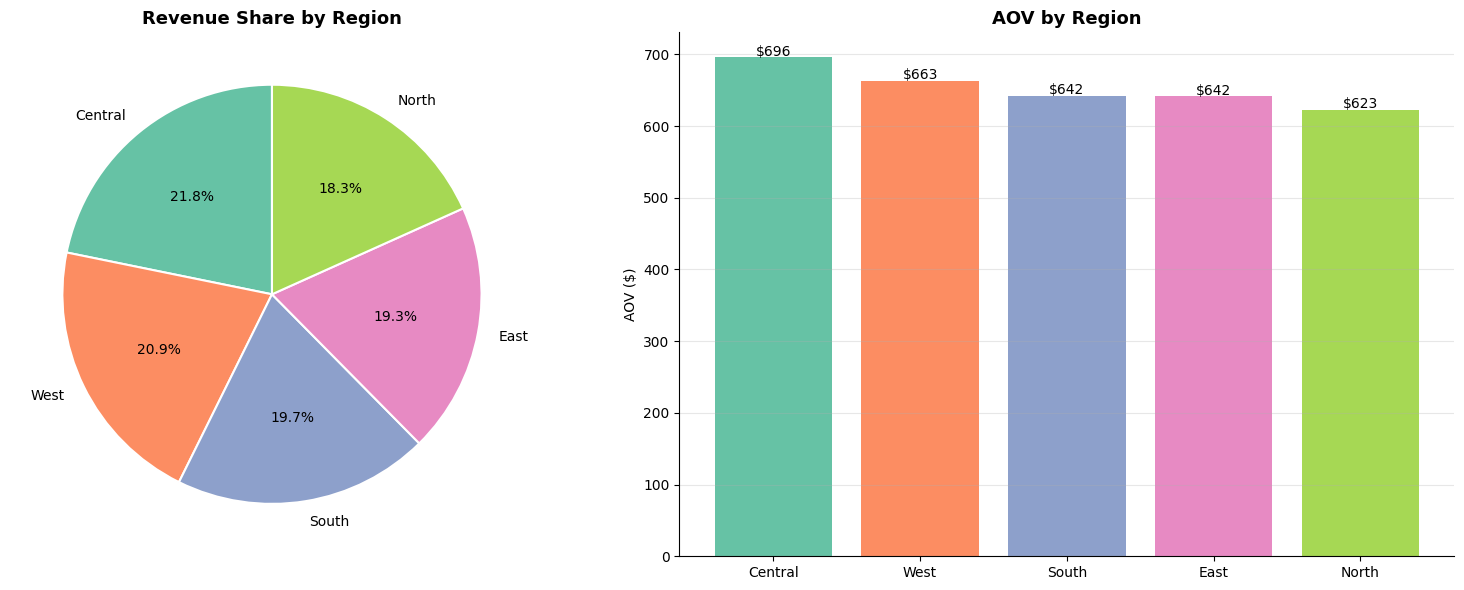

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(region_data['revenue'], labels=region_data.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(region_data)), startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':1.5})
axes[0].set_title('Revenue Share by Region', fontsize=13, fontweight='bold')

colors = sns.color_palette('Set2', len(region_data))
bars = axes[1].bar(region_data.index, region_data['aov'], color=colors)
axes[1].set_title('AOV by Region', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AOV ($)')
for bar, val in zip(bars, region_data['aov']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'${val:.0f}', ha='center', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/03_regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

regions are pretty evenly split, no huge outlier. AOV differences are small.

---
### customer segments

In [16]:
seg = df.groupby('customer_segment').agg(
    revenue=('total_amount','sum'),
    orders=('order_id','count'),
    avg_rating=('customer_rating','mean'),
    avg_discount=('discount_pct','mean')
).round(2)
seg['revenue_share'] = (seg['revenue'] / seg['revenue'].sum() * 100).round(1)
seg

,revenue,orders,avg_rating,avg_discount,revenue_share
customer_segment,,,,,
New,1890916.15,2965,3.57,8.44,28.9
Premium,1328282.86,1988,3.57,8.42,20.3
Returning,2679888.89,4068,3.56,8.64,41.0
VIP,637399.94,979,3.60,7.99,9.8


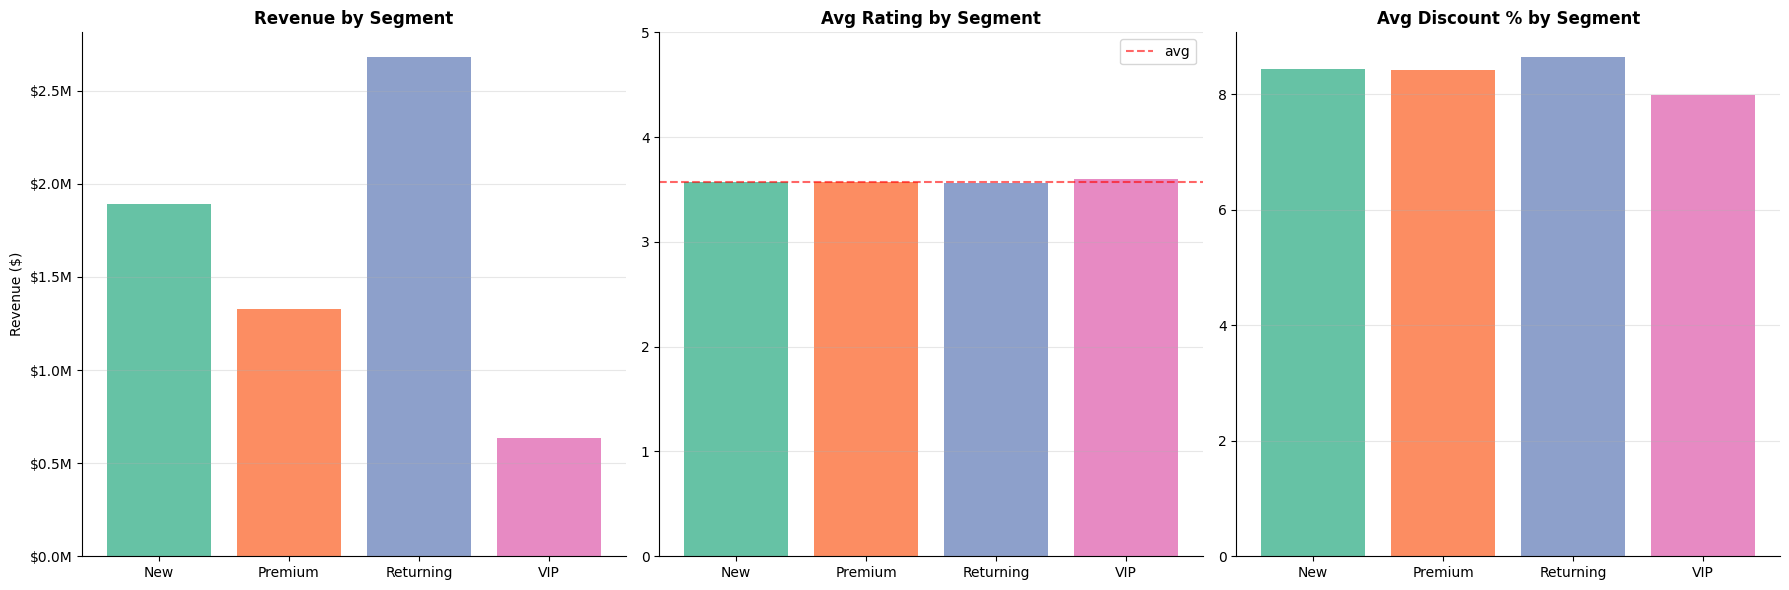

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = sns.color_palette('Set2', 4)

axes[0].bar(seg.index, seg['revenue'], color=colors)
axes[0].set_title('Revenue by Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(seg.index, seg['avg_rating'], color=colors)
axes[1].set_title('Avg Rating by Segment', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 5)
axes[1].axhline(y=seg['avg_rating'].mean(), color='red', linestyle='--', alpha=0.6, label='avg')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(seg.index, seg['avg_discount'], color=colors)
axes[2].set_title('Avg Discount % by Segment', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/04_customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

returning customers make up the biggest revenue share just because there are more of them. VIP AOV is higher but they're a small group. discount percentages being similar across segments surprised me a bit — would have expected VIPs to be targeted differently.

---
### sales channels

In [18]:
channel = df.groupby('sales_channel').agg(
    revenue=('total_amount','sum'),
    orders=('order_id','count'),
    aov=('total_amount','mean'),
    avg_rating=('customer_rating','mean')
).round(2).sort_values('revenue', ascending=False)

channel

,revenue,orders,aov,avg_rating
sales_channel,,,,
Website,2590501.06,4081,634.77,3.58
Mobile App,2322127.74,3489,665.56,3.55
Marketplace,942840.10,1436,656.57,3.58
Social Media,681018.94,994,685.13,3.57


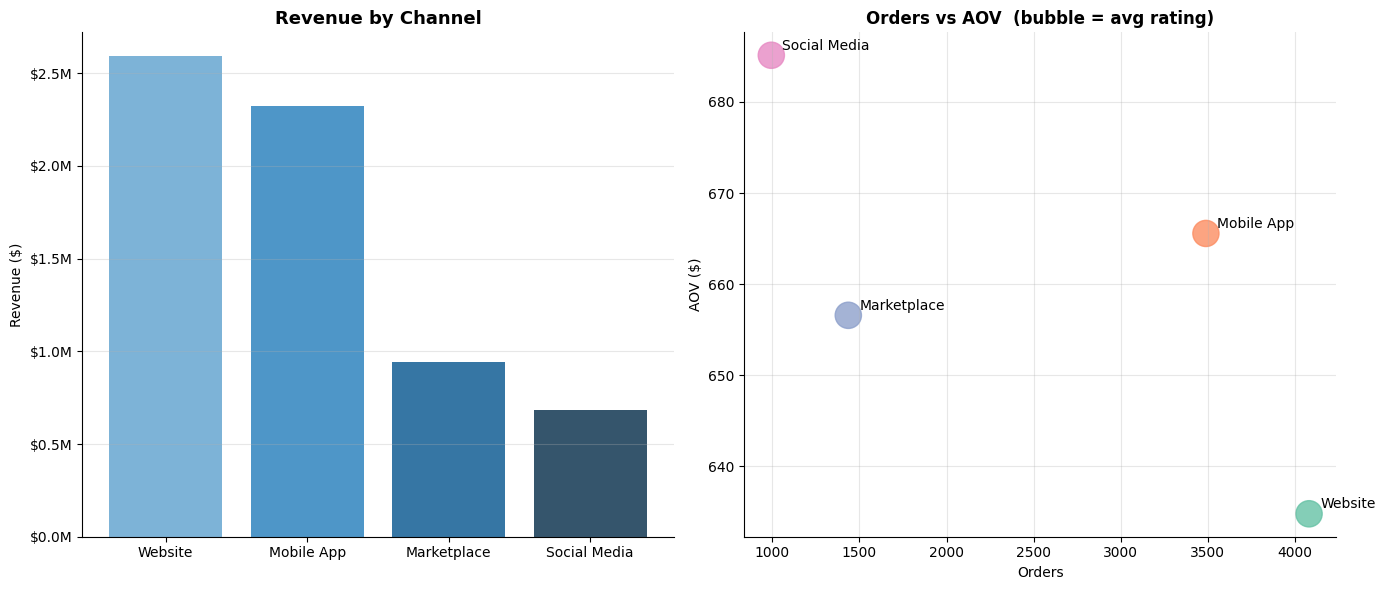

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(channel.index, channel['revenue'],
            color=sns.color_palette('Blues_d', len(channel)))
axes[0].set_title('Revenue by Channel', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].grid(axis='y', alpha=0.3)

# scatter: orders vs aov, bubble = rating
axes[1].scatter(channel['orders'], channel['aov'],
                s=channel['avg_rating']*100, alpha=0.8,
                color=sns.color_palette('Set2', len(channel)))
for idx, row in channel.iterrows():
    axes[1].annotate(idx, (row['orders'], row['aov']),
                     textcoords='offset points', xytext=(8, 4), fontsize=10)
axes[1].set_title('Orders vs AOV  (bubble = avg rating)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Orders')
axes[1].set_ylabel('AOV ($)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/05_channel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
### discounts

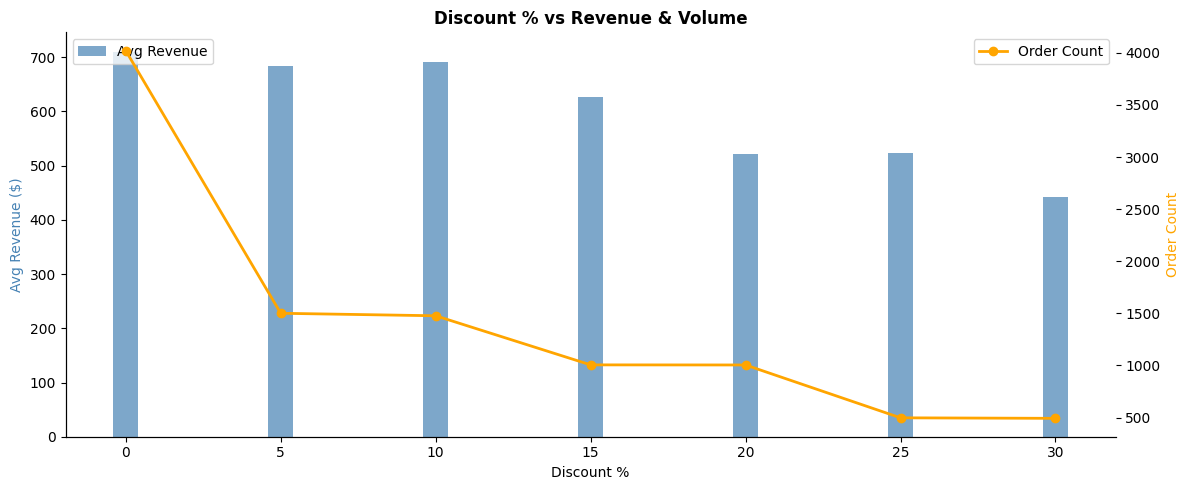

In [20]:
disc = df.groupby('discount_pct').agg(
    avg_revenue=('total_amount','mean'),
    order_count=('order_id','count')
).reset_index()

# plot both on same chart with dual axis
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(disc['discount_pct'], disc['avg_revenue'], color='steelblue', alpha=0.7, label='Avg Revenue')
ax2.plot(disc['discount_pct'], disc['order_count'], color='orange', marker='o', linewidth=2, label='Order Count')

ax1.set_xlabel('Discount %')
ax1.set_ylabel('Avg Revenue ($)', color='steelblue')
ax2.set_ylabel('Order Count', color='orange')
ax1.set_title('Discount % vs Revenue & Volume', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../images/06_discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()

order volume doesn't really increase much once discount goes past 15-20%. probably not worth giving away margin above that.

---
### returns

In [21]:
df['order_status'].value_counts(normalize=True).mul(100).round(1)

order_status
Delivered    75.1
Cancelled     9.9
Returned      9.8
Pending       5.1
Name: proportion, dtype: float64

In [22]:
# return rate by category
ret = df[df['order_status']=='Returned'].groupby('category')['order_id'].count()
total = df.groupby('category')['order_id'].count()
return_rate = (ret / total * 100).sort_values(ascending=True).round(2)
return_rate

category
Beauty & Personal Care     8.58
Books                      9.29
Clothing                   9.92
Electronics               10.14
Home & Kitchen            10.30
Sports & Outdoors         10.84
Name: order_id, dtype: float64

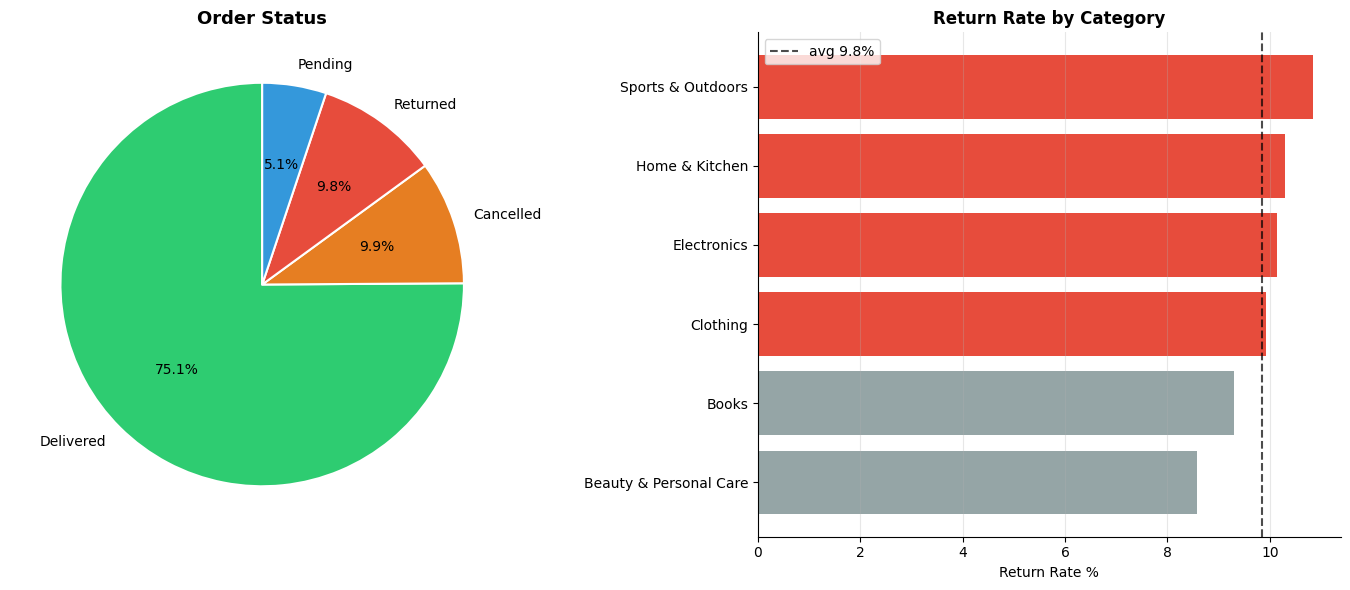

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

status_counts = df['order_status'].value_counts()
colors_map = {'Delivered':'#2ecc71','Returned':'#e74c3c','Cancelled':'#e67e22','Pending':'#3498db'}
colors_list = [colors_map.get(s, 'gray') for s in status_counts.index]

axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
             colors=colors_list, wedgeprops={'edgecolor':'white','linewidth':1.5}, startangle=90)
axes[0].set_title('Order Status', fontsize=13, fontweight='bold')

axes[1].barh(return_rate.index, return_rate.values,
              color=['#e74c3c' if v > return_rate.mean() else '#95a5a6' for v in return_rate.values])
axes[1].axvline(return_rate.mean(), color='black', linestyle='--', alpha=0.7,
                 label=f'avg {return_rate.mean():.1f}%')
axes[1].set_title('Return Rate by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Return Rate %')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/07_returns_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
### correlations

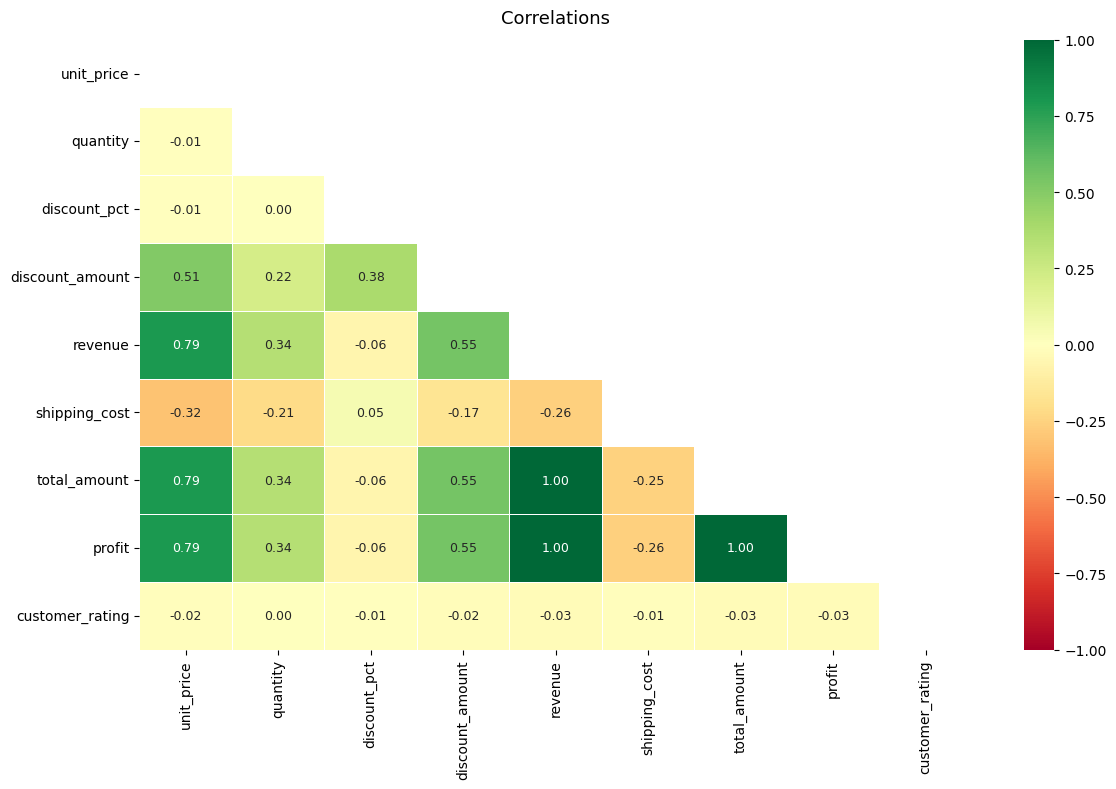

In [24]:
num_cols = ['unit_price','quantity','discount_pct','discount_amount',
             'revenue','shipping_cost','total_amount','profit','customer_rating']

plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlations', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../images/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

revenue and profit are obviously correlated (profit is derived from revenue). discount_amount correlates with unit_price which makes sense — bigger ticket items have larger absolute discounts even at the same percentage.

---

that's the main EDA done. key things:
- electronics = highest revenue, highest return rate
- Q4 is the big season every year
- discounts above ~15% don't seem worth it
- mobile app channel is worth watching

moving on to SQL analysis next